# Run this first !
Ensures correct libraries and imports data

In [1]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


In [2]:
# Start timer
import time
start_time = time.time()

# Import UBS data

In [3]:
# Import data
import pandas as pd

data = pd.read_csv('/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/BERTopic_Test/sentiment_classification_output_UBS.csv')

In [4]:
data.head(5)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
0,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,Neutral,0.633788,0.363612,2.599858e-03,6.337882e-01,RBT_neutral,0.585431,0.059447,0.585431,0.355122
1,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,Neutral,0.762569,0.000298,2.371330e-01,7.625688e-01,RBT_neutral,0.798390,0.040205,0.798390,0.161405
2,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,Neutral,0.995665,0.001492,2.842489e-03,9.956655e-01,RBT_neutral,0.609302,0.021320,0.609302,0.369378
3,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,Positive,1.000000,1.000000,1.214168e-07,7.975387e-08,RBT_positive,0.747497,0.004000,0.248504,0.747497
4,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,Positive,0.999991,0.999991,3.106961e-06,6.054839e-06,RBT_positive,0.880521,0.003450,0.116029,0.880521


# Filter data for sentences = "Negative" by FinBERT

In [5]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
360,2022-Q1,Amit Goel,analyst,So what you're seeing there and whether the ma...,"['youre', 'seeing', 'whether', 'margin', 'stab...",negative,0.562937
393,2022-Q1,Adam Terelak,analyst,I think that's the level when in previous cycl...,"['think', 'thats', 'level', 'previous', 'cycle...",negative,0.913481
448,2022-Q1,Flora Bocahut,analyst,And how much of this do you think could be rev...,"['much', 'think', 'could', 'reversed', 'coming...",negative,0.732441
449,2022-Q1,Flora Bocahut,analyst,The second question is regarding the client be...,"['second', 'question', 'regarding', 'client', ...",negative,0.837717


In [6]:
negative_sentences.shape

(764, 7)

## Apply BERTopic to raw sentences

In [7]:
# Build topics from negative sentences only. The CSV stores cleaned_text as a
# serialized list, so use original sentences rather than joining its characters.
from bertopic import BERTopic
from umap import UMAP

negative_sentences_list = (
    data.loc[data["main_sentiment"].eq("negative"), "sentence"]
    .dropna()
    .astype(str)
    .tolist()
)

topic_model = BERTopic(
    umap_model=UMAP(random_state=42, n_jobs=1),
    calculate_probabilities=False,
)
topics, probs = topic_model.fit_transform(negative_sentences_list)
topic_model.get_topic_info()

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8901.62it/s]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,268,-1_the_in_and_to,"[the, in, and, to, of, that, you, on, we, so]",[So that's what I mean by the impact from depo...
1,0,68,0_expenses_operating_compensation_and,"[expenses, operating, compensation, and, perso...",[Operating expenses were down 4% on lower pers...
2,1,63,1_revenues_lower_by_fees,"[revenues, lower, by, fees, decreased, in, pro...","[Total revenue decreased 31%, with lower net m..."
3,2,54,2_of_the_cost_we,"[of, the, cost, we, to, gross, saves, and, cos...",[Of the around 13 billion in gross cost saves ...
4,3,49,3_ncl_billion_of_rwa,"[ncl, billion, of, rwa, the, around, to, in, i...","[For the remainder of the year, we expect NCL ..."
5,4,42,4_nii_in_expect_the,"[nii, in, expect, the, rate, to, percentage, b...","[For the first quarter, we expect a low single..."
6,5,38,5_capital_cet1_the_ratio,"[capital, cet1, the, ratio, our, of, to, paren...",[Our CET1 capital ratio at the end of December...
7,6,32,6_credit_suisse_the_suisses,"[credit, suisse, the, suisses, of, loss, and, ...",[Credit loss expense in the quarter was 154 mi...
8,7,23,7_geopolitical_macroeconomic_and_uncertainty,"[geopolitical, macroeconomic, and, uncertainty...","[However, continued elevated geopolitical and ..."
9,8,23,8_quarter_the_we_in,"[quarter, the, we, in, bit, seeing, fourth, so...",[And probably had the inverse dynamic happenin...


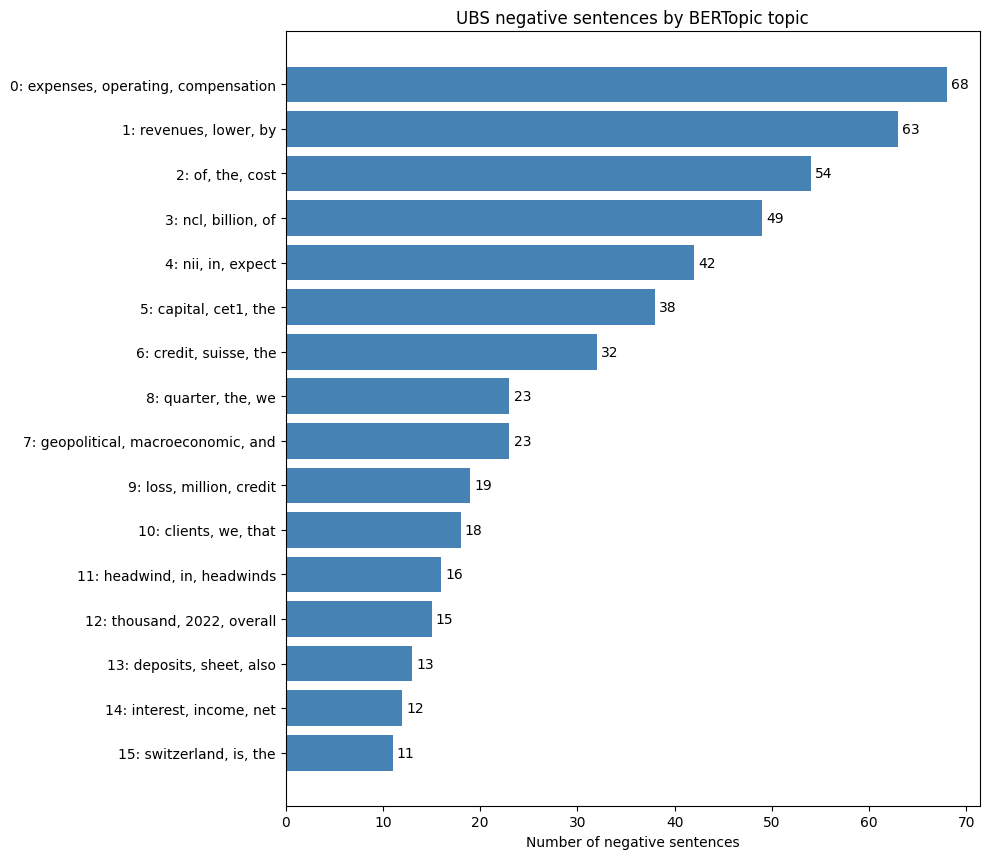

In [8]:
import matplotlib.pyplot as plt

topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1]  # drop the outlier "topic"
topic_info = topic_info.sort_values("Count")

# Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
labels = [
    f"{row.Topic}: " + ", ".join(row.Name.split("_")[1:4])
    for row in topic_info.itertuples()
]

fig, ax = plt.subplots(figsize=(10, 0.45 * len(topic_info) + 1.5))
bars = ax.barh(labels, topic_info["Count"], color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of negative sentences")
ax.set_title("UBS negative sentences by BERTopic topic")
plt.tight_layout()
plt.show()


There is also the issue of small words creeping in as these are the sentences rather than the cleaned text. 
Somehow the cleaned text needs to be amended to allow BERTopic to run

# Apply BERTopic to Cleaned_Text

## Results with all cleaned_text

In [9]:
type(data['cleaned_text'].iloc[0])

str

In [10]:
# Filter data to only have FinBERT = negative
negative_data = data[data['main_sentiment'] == 'negative']

# Adapt text from "strings of lists" format in csv file
import ast
texts_for_bertopic_negative = [" ".join(ast.literal_eval(t)) for t in negative_data["cleaned_text"]]
print("Number of negative sentences for BERTopic modelling:", len(texts_for_bertopic_negative))

Number of negative sentences for BERTopic modelling: 764


In [11]:
texts_for_bertopic_negative[:5]

['first quarter dominated extraordinary geopolitical macro event result russia invasion ukraine',
 'see also trend moving away desktop mobile',
 'people side supporting people ukraine fled country',
 'lower growth expectation dampened investor sentiment especially china inflation already fueling fear tighter monetary policy',
 'volatile market drove trading volume especially emea']

In [12]:
# Remove any empty sentences after adapting the text from "strings of lists" format
texts_for_bertopic_negative = [t for t in texts_for_bertopic_negative if t.strip() != ""]
print("Number of negative sentences for BERTopic modelling after removing empty sentences:", len(texts_for_bertopic_negative))

Number of negative sentences for BERTopic modelling after removing empty sentences: 764


In [13]:
# Re-run BERTopic on the first 100 negative texts
cl_topic_model_negative = BERTopic()


In [14]:
from bertopic import BERTopic
from umap import UMAP

cl_topic_model_negative = BERTopic(
    umap_model=UMAP(random_state=42, n_jobs=1),
    calculate_probabilities=False,
)
cl_topics_negative, _ = cl_topic_model_negative.fit_transform(texts_for_bertopic_negative)
cl_topic_info_negative = cl_topic_model_negative.get_topic_info()
cl_topic_info_negative

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12931.82it/s]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,268,-1_quarter_revenue_billion_million,"[quarter, revenue, billion, million, market, s...",[pc delivered first quarter pretax profit mill...
1,0,130,0_expense_operating_cost_compensation,"[expense, operating, cost, compensation, litig...",[underlying operating expense lower personnel ...
2,1,97,1_deposit_rate_nii_balance,"[deposit, rate, nii, balance, swiss, decline, ...",[net interest income billion yearoveryear quar...
3,2,59,2_credit_suisse_loss_million,"[credit, suisse, loss, million, expense, ib, q...","[net credit loss expense million, slide credit..."
4,3,52,3_capital_cet_ratio_would,"[capital, cet, ratio, would, parent, requireme...",[ended year sequentially unchanged cet capital...
5,4,45,4_ncl_billion_rwa_around,"[ncl, billion, rwa, around, expect, ncls, unde...",[also expect ncl exit around billion rwas cons...
6,5,35,5_fee_net_revenue_lower,"[fee, net, revenue, lower, management, decreas...",[profit tax million total revenue decreased ex...
7,6,28,6_client_equity_market_macroeconomic,"[client, equity, market, macroeconomic, activi...",[let start fourth quarter revenue slide additi...
8,7,22,7_quarter_worse_slide_second,"[quarter, worse, slide, second, even, seeing, ...",[fx volatility saw quarter specific dollar wea...
9,8,17,8_geopolitical_investor_sentiment_uncertainty,"[geopolitical, investor, sentiment, uncertaint...",[however continued elevated geopolitical econo...


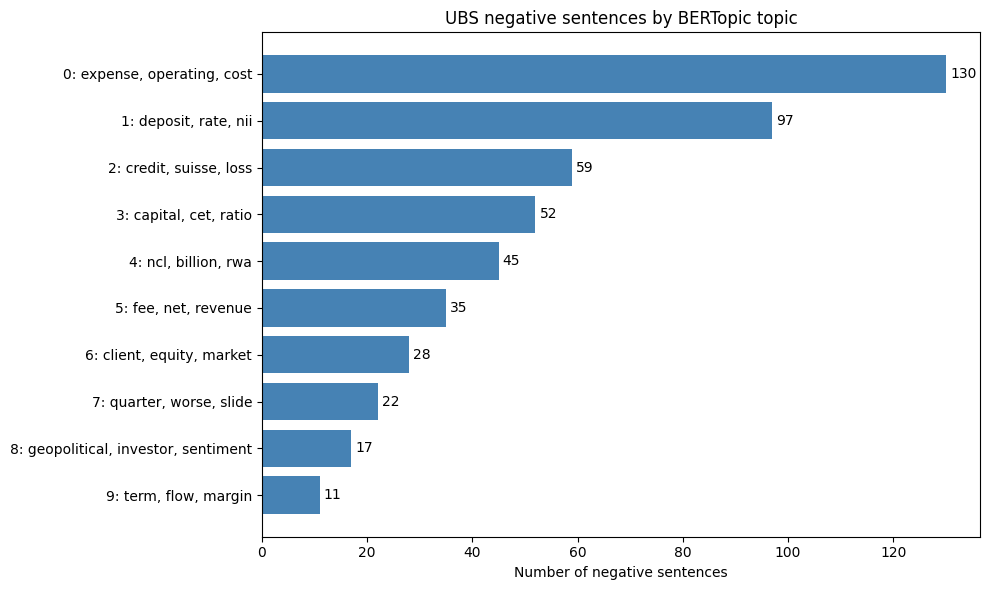

In [15]:

import matplotlib.pyplot as plt

topic_info = cl_topic_info_negative
topic_info = topic_info[topic_info["Topic"] != -1]  # drop the outlier "topic"
topic_info = topic_info.sort_values("Count")
topic_info = topic_info[topic_info["Topic"] != -1]  # drop the outlier "topic"
topic_info = topic_info.sort_values("Count")

# Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
labels = [
    f"{row.Topic}: " + ", ".join(row.Name.split("_")[1:4])
    for row in topic_info.itertuples()
]

fig, ax = plt.subplots(figsize=(10, 0.45 * len(topic_info) + 1.5))
bars = ax.barh(labels, topic_info["Count"], color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of negative sentences")
ax.set_title("UBS negative sentences by BERTopic topic")
plt.tight_layout()
plt.show()

## Comparison to Jack's work
Jack seems to have plotted the top 3 topics by bank per quarter as a vertical graph.  

This would mean running BERTopic separately for each bank and each quarter, extracting the top 3 topics, and then plotting them in a vertical bar chart.  

However the number of negative sentences is much lower hence plots will be done per year rather than per quarter

## Results for 2023 with cleaned_text

In [16]:
# Filter data to only have FinBERT = negative and quarter = Q1 2023, Q2 2023, Q3 2023 and Q4 2023
# Set year for filtering negative sentences
YEAR = '2023'

YR_negative_data = data[(data['main_sentiment'] == 'negative') & (data['quarter'].isin([f'{YEAR}-Q1', f'{YEAR}-Q2', f'{YEAR}-Q3', f'{YEAR}-Q4']))]

# Adapt text from "strings of lists" format in csv file
import ast
YR_texts_for_bertopic_negative = [" ".join(ast.literal_eval(t)) for t in YR_negative_data["cleaned_text"]]
print(f"Number of negative sentences for BERTopic modelling in {YEAR}:", len(YR_texts_for_bertopic_negative))

Number of negative sentences for BERTopic modelling in 2023: 227


In [17]:
YR_texts_for_bertopic_negative[:5]

['performance quarter demonstrates continue source stability client period significant uncertainty',
 'client first quarter largely continuation theme',
 'compared last year strong first quarter institutional client less active particularly equity derivative cash lacked conviction uncertain market',
 'result effort restored trust stakeholder materially derisked business generated significant amount capital shareholder',
 'activity outside strategic focus risk appetite rundown best interest shareholder minimizing risk potential loss swiss taxpayer']

In [18]:
# Remove any empty sentences after adapting the text from "strings of lists" format
YR_texts_for_bertopic_negative = [t for t in YR_texts_for_bertopic_negative if t.strip() != ""]
print(f"Number of negative sentences for BERTopic modelling in {YEAR} after removing empty sentences:", len(YR_texts_for_bertopic_negative))

Number of negative sentences for BERTopic modelling in 2023 after removing empty sentences: 227


In [19]:
# Re-run BERTopic on the first 100 negative texts
YR_cl_topic_model_negative = BERTopic()


In [20]:
from bertopic import BERTopic
from umap import UMAP

YR_cl_topic_model_negative = BERTopic(
    umap_model=UMAP(random_state=42, n_jobs=1),
    calculate_probabilities=False,
)
YR_cl_topics_negative, _ = YR_cl_topic_model_negative.fit_transform(YR_texts_for_bertopic_negative)
YR_cl_topic_info_negative = YR_cl_topic_model_negative.get_topic_info()
YR_cl_topic_info_negative

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21529.62it/s]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_quarter_capital_cet_third,"[quarter, capital, cet, third, million, six, l...",[regarding swiss national bank recently announ...
1,0,138,0_billion_cost_expense_revenue,"[billion, cost, expense, revenue, quarter, low...",[underlying operating expense roughly unchange...
2,1,40,1_credit_suisse_loss_swiss,"[credit, suisse, loss, swiss, million, quarter...",[credit loss expense quarter million swiss fra...
3,2,23,2_deposit_decline_nii_digit,"[deposit, decline, nii, digit, bit, mix, midsi...",[think said decline q expected midsingledigit ...


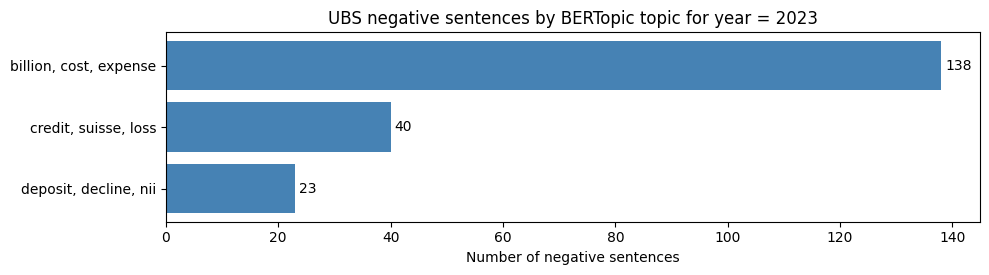

In [21]:

import matplotlib.pyplot as plt

YR_topic_info = YR_cl_topic_info_negative
YR_topic_info = YR_topic_info[YR_topic_info["Topic"] != -1]  # drop the outlier "topic"
YR_topic_info = YR_topic_info.sort_values("Count")
YR_topic_info = YR_topic_info[YR_topic_info["Topic"] != -1]  # drop the outlier "topic"
YR_topic_info = YR_topic_info.sort_values("Count")

# Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
labels = [
    f"{row.Topic}: " + ", ".join(row.Name.split("_")[1:4])
    for row in YR_topic_info.itertuples()
]

# Remove cluster number from the labels
labels = [", ".join(label.split(": ")[1:]) for label in labels]
fig, ax = plt.subplots(figsize=(10, 0.45 * len(YR_topic_info) + 1.5))
bars = ax.barh(labels, YR_topic_info["Count"], color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of negative sentences")
ax.set_title(f"UBS negative sentences by BERTopic topic for year = {YEAR}")
plt.tight_layout()
plt.show()

# Convert to function for any year

In [22]:
import ast
import matplotlib.pyplot as plt
from bertopic import BERTopic
from umap import UMAP


def plot_negative_topics_for_year(data, year, bank="UBS", min_topic_size=10, top_n_words=3):
    """Run BERTopic on a year's negative sentences and plot topic counts as a bar chart.

    Returns (topic_model, topic_info), or (None, None) if no topics were found.
    """
    year = str(year)
    quarters = [f"{year}-Q{q}" for q in range(1, 5)]

    # Negative sentences for the year
    yr_data = data[(data["main_sentiment"] == "negative") & (data["quarter"].isin(quarters))]

    # Adapt text from "strings of lists" format in csv file, dropping empty sentences
    texts = [" ".join(ast.literal_eval(t)) for t in yr_data["cleaned_text"]]
    texts = [t for t in texts if t.strip() != ""]
    print(f"Number of negative sentences for BERTopic modelling in {year}: {len(texts)}")

    topic_model = BERTopic(
        umap_model=UMAP(random_state=42, n_jobs=1),
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
    )
    topic_model.fit_transform(texts)
    topic_info = topic_model.get_topic_info()

    plot_info = topic_info[topic_info["Topic"] != -1].sort_values("Count")  # drop the outlier "topic"
    if plot_info.empty:
        print(f"No topics found for {year} (only outliers); try a smaller min_topic_size.")
        return None, topic_info

    # Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
    labels = [", ".join(name.split("_")[1:1 + top_n_words]) for name in plot_info["Name"]]

    fig, ax = plt.subplots(figsize=(10, 0.45 * len(plot_info) + 1.5))
    bars = ax.barh(labels, plot_info["Count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of negative sentences")
    ax.set_title(f"{bank} negative sentences by BERTopic topic for year = {year}")
    plt.tight_layout()
    plt.show()
    return topic_model, topic_info


Number of negative sentences for BERTopic modelling in 2022: 153


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8939.38it/s]


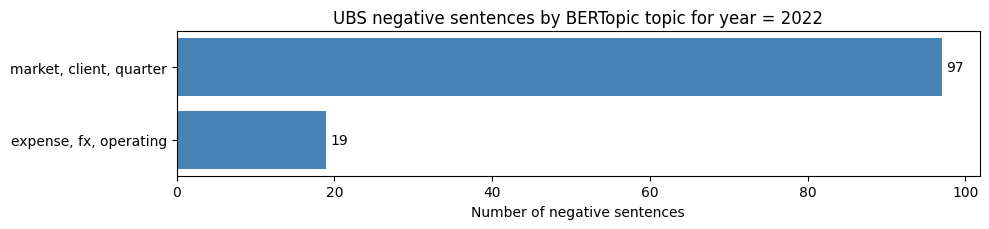

In [24]:
YR_topic_model_22, YR_topic_info_22 = plot_negative_topics_for_year(data, "2022")

Number of negative sentences for BERTopic modelling in 2023: 227


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6194.36it/s]


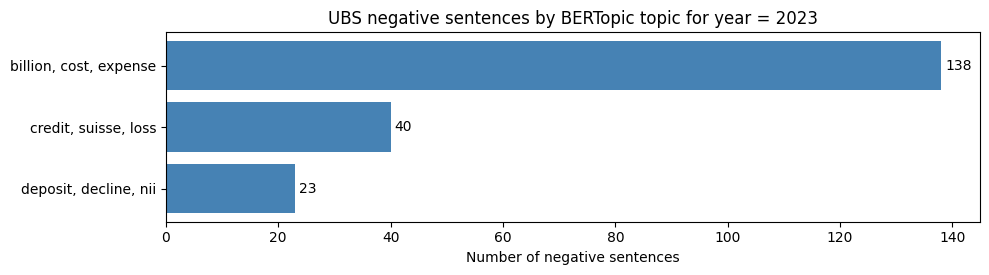

In [26]:
YR_topic_model_23, YR_topic_info_23 = plot_negative_topics_for_year(data, "2023")

Number of negative sentences for BERTopic modelling in 2024: 212


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6181.42it/s]


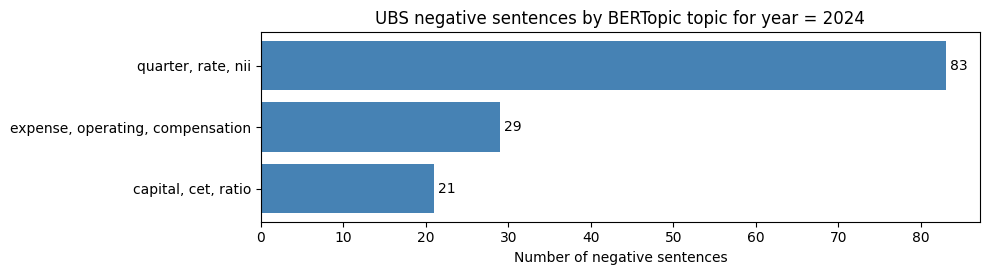

In [27]:
YR_topic_model_24, YR_topic_info_24 = plot_negative_topics_for_year(data, "2024")

Number of negative sentences for BERTopic modelling in 2025: 172


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7404.21it/s]


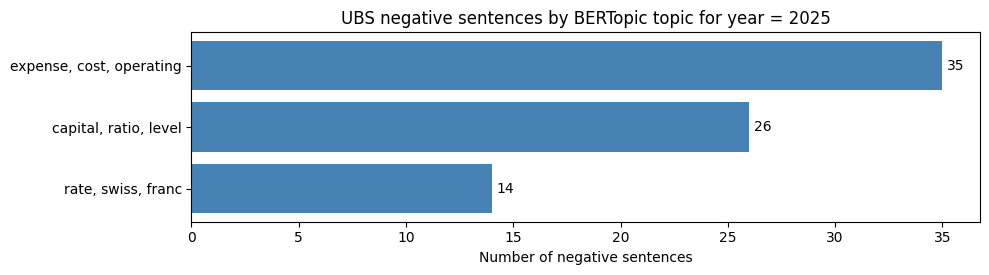

In [28]:
YR_topic_model_25, YR_topic_info_25 = plot_negative_topics_for_year(data, "2025")

In [54]:
# Collect yr_topic_info for all years into one dataframe for plotting, include year as a column
all_YR_topic_info = pd.concat([
    YR_topic_info_22.assign(year="2022"),
    YR_topic_info_23.assign(year="2023"),
    YR_topic_info_24.assign(year="2024"),
    YR_topic_info_25.assign(year="2025")
])
all_YR_topic_info.reset_index(drop=True, inplace=True)

all_YR_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs,year
0,-1,37,-1_million_loss_credit_pressure,"[million, loss, credit, pressure, net, cost, q...","[net credit loss expense million, credit loss ...",2022
1,0,97,0_market_client_quarter_also,"[market, client, quarter, also, lower, revenue...",[let start fourth quarter revenue slide additi...,2022
2,1,19,1_expense_fx_operating_compensation,"[expense, fx, operating, compensation, exlitig...",[operating expense exlitigation fx flat versus...,2022
3,-1,26,-1_quarter_capital_cet_third,"[quarter, capital, cet, third, million, six, l...",[regarding swiss national bank recently announ...,2023
4,0,138,0_billion_cost_expense_revenue,"[billion, cost, expense, revenue, quarter, low...",[underlying operating expense roughly unchange...,2023


In [57]:
# Add new column for plotting as legend to all_YR_topic_info
# remove numbers and replace underscores with commas
all_YR_topic_info["Legend"] = all_YR_topic_info["Name"].apply(
    lambda x: ", ".join(x.split("_")[1:])
)
all_YR_topic_info.head()



,Topic,Count,Name,Representation,Representative_Docs,year,Legend
0,-1,37,-1_million_loss_credit_pressure,"[million, loss, credit, pressure, net, cost, q...","[net credit loss expense million, credit loss ...",2022,"million, loss, credit, pressure"
1,0,97,0_market_client_quarter_also,"[market, client, quarter, also, lower, revenue...",[let start fourth quarter revenue slide additi...,2022,"market, client, quarter, also"
2,1,19,1_expense_fx_operating_compensation,"[expense, fx, operating, compensation, exlitig...",[operating expense exlitigation fx flat versus...,2022,"expense, fx, operating, compensation"
3,-1,26,-1_quarter_capital_cet_third,"[quarter, capital, cet, third, million, six, l...",[regarding swiss national bank recently announ...,2023,"quarter, capital, cet, third"
4,0,138,0_billion_cost_expense_revenue,"[billion, cost, expense, revenue, quarter, low...",[underlying operating expense roughly unchange...,2023,"billion, cost, expense, revenue"


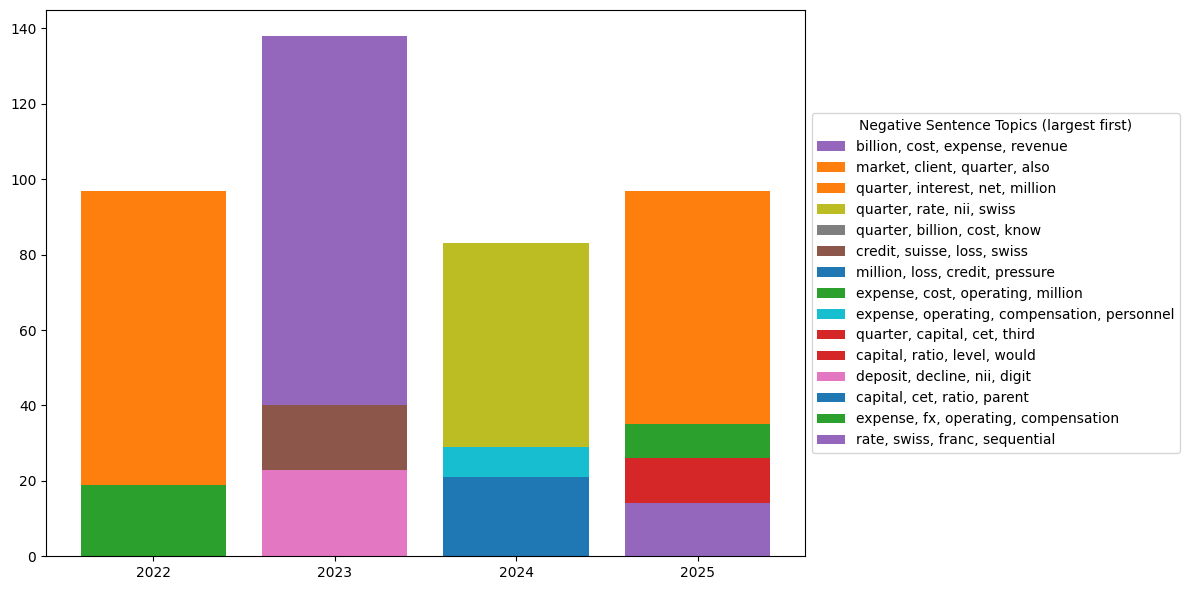

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for topic in all_YR_topic_info["Name"].unique():
    topic_data = all_YR_topic_info[all_YR_topic_info["Name"] == topic]
    ax.bar(topic_data["year"], topic_data["Count"], label=topic_data["Legend"].iloc[0])

# Total count per legend label, used for ordering
totals = all_YR_topic_info.groupby("Legend")["Count"].sum()

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: totals[labels[i]], reverse=True)

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # legend at the side
    title="Negative Sentence Topics (largest first)",
)
plt.tight_layout()
plt.show()